In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [72]:
import pandas as pd

df = pd.read_csv("dataset/PJME_hourly.csv")
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [73]:
df.columns = ["datetime", "energy"]

df["datetime"] = pd.to_datetime(df["datetime"])

df = df.sort_values("datetime")

df.head()

,datetime,energy
8734,2002-01-01 01:00:00,30393.0
8735,2002-01-01 02:00:00,29265.0
8736,2002-01-01 03:00:00,28357.0
8737,2002-01-01 04:00:00,27899.0
8738,2002-01-01 05:00:00,28057.0


In [75]:
daily_df = df.resample("D", on="datetime").sum()

daily_df.head()

,energy
datetime,
2002-01-01,714857.0
2002-01-02,822277.0
2002-01-03,828285.0
2002-01-04,809171.0
2002-01-05,729723.0


In [76]:
daily_df["day_of_week"] = daily_df.index.dayofweek
daily_df["month"] = daily_df.index.month
daily_df["day_of_year"] = daily_df.index.dayofyear
daily_df["week_of_year"] = daily_df.index.isocalendar().week.astype(int)
daily_df["quarter"] = daily_df.index.quarter

daily_df.head()

,energy,day_of_week,month,day_of_year,week_of_year,quarter
datetime,,,,,,
2002-01-01,714857.0,1,1,1,1,1
2002-01-02,822277.0,2,1,2,1,1
2002-01-03,828285.0,3,1,3,1,1
2002-01-04,809171.0,4,1,4,1,1
2002-01-05,729723.0,5,1,5,1,1


In [81]:
# lag features
daily_df["lag_1"] = daily_df["energy"].shift(1)
daily_df["lag_7"] = daily_df["energy"].shift(7)
daily_df["lag_14"] = daily_df["energy"].shift(14)
daily_df["lag_30"] = daily_df["energy"].shift(30)

# rolling statistics
daily_df["rolling_mean_7"] = daily_df["energy"].rolling(window=7).mean()
daily_df["rolling_std_7"] = daily_df["energy"].rolling(window=7).std()
daily_df["rolling_mean_14"] = daily_df["energy"].rolling(window=14).mean()
daily_df["rolling_std_14"] = daily_df["energy"].rolling(window=14).std()

In [82]:
daily_df = daily_df.dropna()

daily_df.head()

,energy,day_of_week,month,day_of_year,week_of_year,quarter,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14
datetime,,,,,,,,,,,,,,
2002-03-02,683816.0,5,3,61,9,1,756887.0,662570.0,644450.0,729020.0,721620.714286,47470.789695,710281.571429,43107.532736
2002-03-03,615464.0,6,3,62,9,1,683816.0,648815.0,645198.0,711909.0,716856.285714,56760.509663,708157.714286,47107.668602
2002-03-04,774052.0,0,3,63,10,1,615464.0,718081.0,742299.0,687530.0,724852.142857,60762.990972,710425.785714,49577.548550
2002-03-05,817351.0,1,3,64,10,1,774052.0,703666.0,747740.0,686370.0,741092.857143,68815.825155,715398.000000,56600.939932
2002-03-06,747963.0,2,3,65,10,1,817351.0,753861.0,712180.0,781528.0,740250.285714,68669.389900,717953.928571,57248.666847


In [83]:
daily_df.shape

(5999, 14)

In [98]:
X = daily_df[[
    "lag_1",
    "day_of_week",
    "rolling_mean_7",
    "rolling_std_7",
    "lag_7"
]]
y = daily_df["energy"]

X.head()

,lag_1,day_of_week,rolling_mean_7,rolling_std_7,lag_7
datetime,,,,,
2002-03-02,756887.0,5,721620.714286,47470.789695,662570.0
2002-03-03,683816.0,6,716856.285714,56760.509663,648815.0
2002-03-04,615464.0,0,724852.142857,60762.990972,718081.0
2002-03-05,774052.0,1,741092.857143,68815.825155,703666.0
2002-03-06,817351.0,2,740250.285714,68669.389900,753861.0


In [99]:
y.head()

,energy
datetime,
2002-03-02,683816.0
2002-03-03,615464.0
2002-03-04,774052.0
2002-03-05,817351.0
2002-03-06,747963.0


In [100]:
train_size = int(len(daily_df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)
print(X_test.shape)

(4799, 5)
(1200, 5)


In [104]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=400,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

import joblib
joblib.dump(model, "energy_model.pkl")

y_pred = model.predict(X_test)

In [103]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 34154.0128163872
RMSE: 50749.408062252165
R2: 0.810824898542604


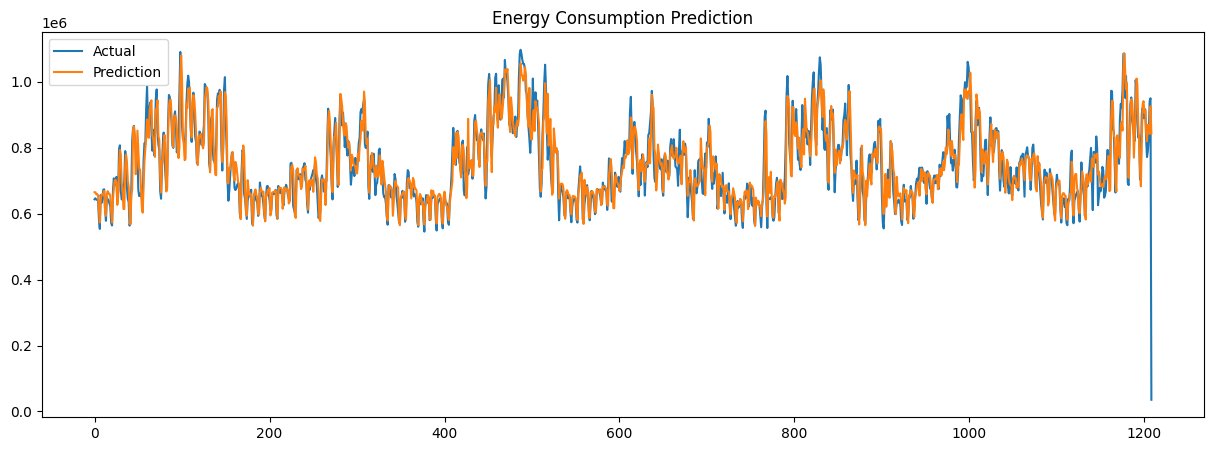

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Prediction")
plt.legend()
plt.title("Energy Consumption Prediction")
plt.show()

lag_1              0.750044
day_of_week        0.091196
rolling_mean_7     0.048384
rolling_std_7      0.027944
lag_7              0.017478
lag_14             0.012893
rolling_mean_14    0.012802
rolling_std_14     0.012343
lag_30             0.012193
day_of_year        0.009045
week_of_year       0.004179
month              0.001149
quarter            0.000349
dtype: float64


<Axes: >

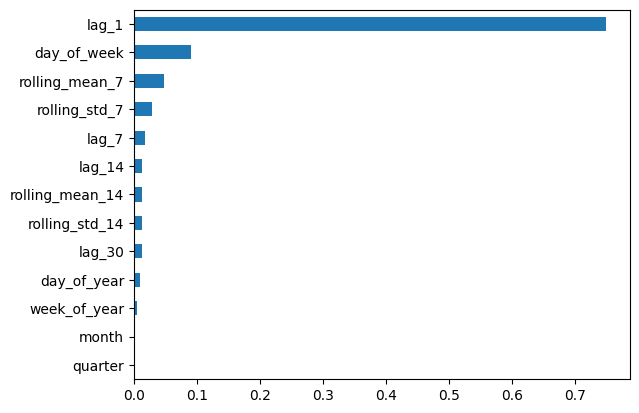

In [97]:
importance = pd.Series(model.feature_importances_, index=X_train.columns)

print(importance.sort_values(ascending=False))

importance.sort_values().plot(kind='barh')

In [106]:
import joblib

# load model yang sudah disimpan
loaded_model = joblib.load("energy_model.pkl")

# coba prediksi lagi
y_pred_loaded = loaded_model.predict(X_test)

print(y_pred_loaded[:10])

[643608.00678483 660421.82918573 669318.60315977 607309.48421095
 590723.71791621 655511.86300429 675635.51994391 656185.27616932
 654835.43575865 646046.43800878]


In [107]:
features = X_train.columns.tolist()

import joblib
joblib.dump(features, "model_features.pkl")

print(features)

['lag_1', 'day_of_week', 'rolling_mean_7', 'rolling_std_7', 'lag_7']


In [108]:
import pandas as pd
import joblib

# load model dan fitur
model = joblib.load("energy_model.pkl")
features = joblib.load("model_features.pkl")

# contoh data baru (harus mengikuti urutan fitur)
sample_input = pd.DataFrame([{
    "lag_1": 640000,
    "day_of_week": 2,
    "rolling_mean_7": 650000,
    "rolling_std_7": 20000,
    "lag_7": 660000
}])

# pastikan urutan fitur sama
sample_input = sample_input[features]

# prediksi
prediction = model.predict(sample_input)

print("Predicted energy:", prediction[0])


Predicted energy: 657629.4768388342
